# In this model we want to do the following:
- Model the white light curve for both visits
- Use fit results to fix the ramp and breathing parameters

In [8]:
import os
import jax
import jax.numpy as jnp
from jax import pmap, devices

# Force CPU mode to avoid the Metal version mismatch
os.environ['JAX_PLATFORMS'] = 'cpu'
os.environ['XLA_FLAGS'] = '--xla_force_host_platform_device_count=8'

# Clear any cached backends
jax.config.update('jax_platform_name', 'cpu')

# Now check devices
print("Available devices:", devices())
print("CPU devices:", devices('cpu'))

import warnings
warnings.filterwarnings("ignore", message="It appears that you're using a Mac with one of Apple's ARM-based processors")

# We need to import numpyro first (though we use it last)
import numpyro
from numpyro.infer import MCMC, NUTS
from numpyro import distributions as dist
# N_cores = 18
# numpyro.set_host_device_count(N_cores)

from preamble_jax import *

Available devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7)]
CPU devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7)]


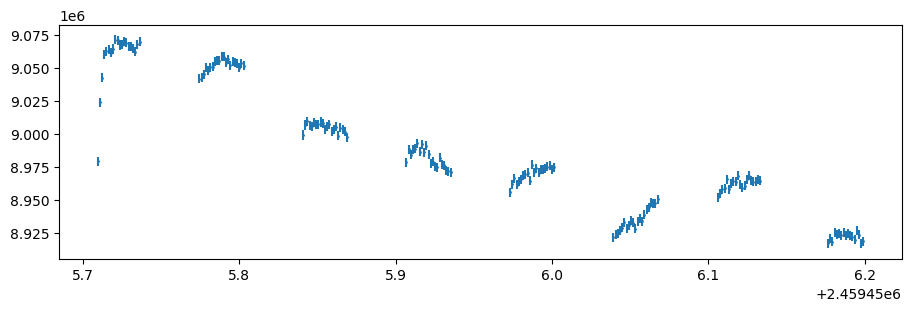

<Figure size 640x480 with 0 Axes>

In [9]:
visit = 'F21'

orbits_to_exclude = np.array([0,2,7])
speclc_bin_edges = F21_speclc_bin_edges if visit=='F21' else S22_speclc_bin_edges
speclc_err_factor = F21_speclc_err_factor if visit=='F21' else S22_speclc_err_factor
SED_err_factor = F21_SED_err_factor if visit=='F21' else S22_SED_err_factor

predicted_T0 = visits[f'{visit}']['T0 (BJD_TDB)'].value
binwidth = visits[f'{visit}']['native resolution']
exptime = visits[f'{visit}']['exp (s)']
grism = visits[f'{visit}']['Grism']
_rainbow = read_rainbow(f"../data/{visit}_scan-combined_trimmed_pacman_spec.rainbow.npy")
rainbow = _rainbow
for i in range(len(_rainbow.wavelength.value)):
    rainbow.uncertainty[i,:] = _rainbow.uncertainty[i,:] * SED_err_factor[i]
speclc_rainbow = rainbow#.bin(wavelength_edges = speclc_bin_edges)
# for i in range(len(speclc_rainbow.wavelength)):
#     speclc_rainbow.uncertainty[i,:] = speclc_rainbow.uncertainty[i,:] * speclc_err_factor[i]

# trim_spots = ( _speclc_rainbow.mask_transit(period=8.463*u.day, t0=(predicted_T0+0.027)*u.day, duration=0.075*u.day).trim() )

# trim_spots.imshow()
# plt.show()
# plt.clf()

# speclc_rainbow = trim_spots.trim()
# speclc_rainbow.time = speclc_rainbow.time + (predicted_T0+0.027)*u.day

# Check a light curve to verify the spots are getting trimmed
plt.figure(figsize=(9,3))
plt.errorbar(speclc_rainbow.time,speclc_rainbow.flux[10,:],speclc_rainbow.uncertainty[10,:],
            fmt='o',ms=1)
plt.show()
plt.clf()

Median relative photon uncertainty at 1.1291 micron = 358ppm
Median relative photon uncertainty at 1.1337 micron = 1491ppm
Median relative photon uncertainty at 1.1383 micron = 1283ppm
Median relative photon uncertainty at 1.1430 micron = 403ppm
Median relative photon uncertainty at 1.1476 micron = 349ppm
Median relative photon uncertainty at 1.1522 micron = 347ppm
Median relative photon uncertainty at 1.1569 micron = 489ppm
Median relative photon uncertainty at 1.1615 micron = 794ppm
Median relative photon uncertainty at 1.1661 micron = 343ppm
Median relative photon uncertainty at 1.1708 micron = 424ppm
Median relative photon uncertainty at 1.1754 micron = 380ppm
Median relative photon uncertainty at 1.1800 micron = 338ppm
Median relative photon uncertainty at 1.1847 micron = 333ppm
Median relative photon uncertainty at 1.1893 micron = 331ppm
Median relative photon uncertainty at 1.1939 micron = 658ppm
Median relative photon uncertainty at 1.1986 micron = 329ppm
Median relative photon

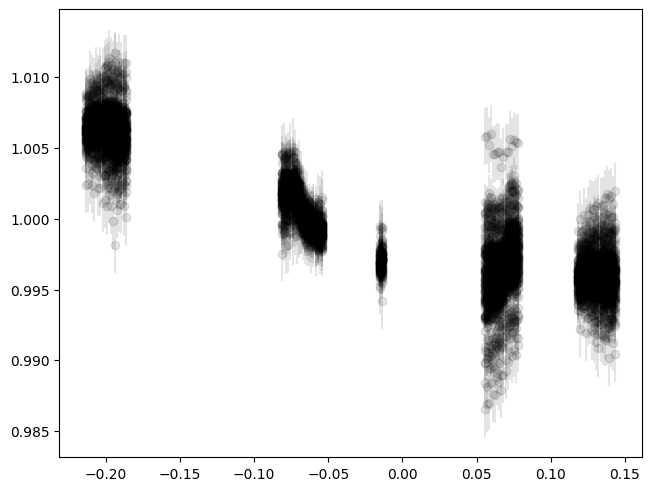

In [10]:
data_wavelengths = speclc_rainbow.wavelength.value
img_date = speclc_rainbow.time.value
data_flux = speclc_rainbow.flux.value
relative_err = speclc_rainbow.uncertainty.value/data_flux
time_from_T0 = img_date - predicted_T0

for i in range(len(data_wavelengths)):
    print(f'Median relative photon uncertainty at {data_wavelengths[i]:.4f} micron = {int(np.nanmedian(relative_err[i,:])*1e6)}ppm')

_w, _s, _e = read_sensitivity_curve(grism=grism)
binned_filter_response = bintogrid(_w.value, _s.value, newx=data_wavelengths)['y'] * u.cm**2 / u.erg

for i,date in enumerate(img_date):
    e_per_s = data_flux[:,i] / exptime
    e_per_s_per_angstrom = e_per_s / binwidth
    calibrated_flux = (e_per_s_per_angstrom.flatten() / binned_filter_response)
    data_flux[:,i] = calibrated_flux.value

# Label the orbits
orbit = np.zeros_like(img_date)
for j in range(len(img_date)):
    if j >= 1:
        if (img_date[j] - img_date[j - 1]) > 0.01:
            orbit[j] = (orbit[j - 1] + 1)
        else:
            orbit[j] = orbit[j - 1]

# Trim the first point from each orbit
ref_time = []
for o in np.unique(orbit):
    first_index = np.where(orbit == o)[0][0]
    ref_time.append(img_date[first_index])
    data_flux[:, first_index] = np.nan  # Set the first point of each subsequent orbit to np.nan
    relative_err[:, first_index] = np.nan
    img_date[first_index] = np.nan
    time_from_T0[first_index] = np.nan

time_from_T0[86:108] = np.nan

# Set data to nan if it was in the pre-defined list of orbits to exclude
for orbit_to_exclude in orbits_to_exclude:
    data_flux[:, orbit == orbit_to_exclude] = np.nan
    relative_err[:, orbit == orbit_to_exclude] = np.nan
    img_date[orbit == orbit_to_exclude] = np.nan
    time_from_T0[orbit == orbit_to_exclude] = np.nan

# Populate ramp_phase time arrays
phase_list=[]
for o in [0,1,2,3,4,5,6,7]:
    rphase = (img_date[orbit==o] - ref_time[o]) / 0.066
    phase_list.append(rphase)
ramp_phase = np.concatenate(phase_list)
breathing_phase = ( (img_date-ref_time[0]+0.02) / 0.066 ) % 1

# Convert all arrays to JAX arrays

data_flux = jnp.array( data_flux[:,~np.isnan(time_from_T0)] )
_relative_err = jnp.array(relative_err[:,~np.isnan(time_from_T0)] )
img_date = jnp.array(img_date[~np.isnan(time_from_T0)] )
# ramp_phase = jnp.array(ramp_phase[~np.isnan(ramp_phase)] )
ramp_phase = jnp.array(ramp_phase[~np.isnan(time_from_T0)] )
# breathing_phase = jnp.array(breathing_phase[~np.isnan(breathing_phase)] )
breathing_phase = jnp.array(breathing_phase[~np.isnan(time_from_T0)] )

time_from_T0 = jnp.array(time_from_T0[~np.isnan(time_from_T0)] )

mean_per_wavelength = jnp.mean(data_flux, axis=1, keepdims=True)
normalized_data_flux = data_flux / mean_per_wavelength
relative_err = _relative_err * normalized_data_flux
jax_rel_err = relative_err
jax_flux = normalized_data_flux

planet_parameters = dict(
    inclination = jnp.radians(89.5),
    a = 19.2, #default_params['a_rstar'],
    rp = 0.047,
    period = 8.46,
    t0 = 0,
    ecc = 0.0,
    u1 = 0.25,
    u2 = 0.15)

# initial_lons = jnp.array(np.random.uniform(-2.8,2.8,n_spots))
# jnp.save('../data/initial_lons',initial_lons)
# initial_lats = jnp.array(random.choice( [np.random.beta(2, 1,n_spots)*(1.25 - 0.2) + 0.2, np.random.beta(1,2,n_spots)*(3.0 - 2.0) + 2.0 ]))
# jnp.save('../data/initial_lats',initial_lats)
# initial_radii = jnp.array([0.005]*n_spots)

for i in range(len(data_wavelengths)):
    plt.errorbar(time_from_T0, normalized_data_flux[i,:], relative_err[i,:],color='k',alpha=0.1,fmt='o')

In [ ]:
def numpyro_model():

    """
    Define the probabilistic model in NUMPYRO
    """
    params = {}

    # Instrument Parameters
    params['r_1'] = numpyro.sample('r_1', dist.Uniform(7.0, 18.0))
    params['r_2'] = numpyro.sample('r_2', dist.Uniform(-8, -1))
    params['r_3'] = numpyro.sample('r_3', dist.Uniform(-0.05,0.05))  

    # Instrument Parameters
    params['b_1'] = #numpyro.sample('b_1', dist.Uniform(-0.08,0.08))
    params['b_2'] = #numpyro.sample('b_2', dist.Uniform(-0.2,0.2))
    params['b_3'] = #numpyro.sample('b_3', dist.Uniform(-0.3,0.3)) 
    params['b_4'] = #numpyro.sample('b_4', dist.Uniform(-0.15,0.1)) 

    # params['HST_period'] = numpyro.sample('HST_period', dist.Uniform(0.0645,0.0675)))

    # Baseline Parameters
    params['linear_slope'] = numpyro.sample('linear_slope', dist.Uniform(-0.15, 0))
    params['rot_spot_lat'] = 1.25 #numpyro.sample('spot_lat', dist.Uniform(0.5, 1.7))
    params['rot_spot_lon'] = 0 #numpyro.sample('rot_spot_lon', dist.Uniform(-1.4, -0.4))
    params['rot_spot_rad'] = 0 #numpyro.sample('rot_spot_rad', dist.Uniform(0.0, 0.4))
    # params['rot_spot_2_lon'] = numpyro.sample('rot_spot_2_lon', dist.Uniform(-2.0, -1.4))

    # Planet Parameters
    params['rp_rs'] = numpyro.sample('rp_rs', dist.Uniform(0.0, 0.2))
    params['t_0'] = 0.00026 #numpyro.sample('t_0', dist.Uniform(0, 0.0015)) 
    params['a'] = 19.15 #numpyro.sample('a', dist.Uniform(18.0, 20.0))
    
    params['u1'] = numpyro.sample('u1', dist.Uniform(0.0,1.0))
    params['u2'] = numpyro.sample('u2', dist.Uniform(0.0,1.0))
    
    # Stellar Parameters
    # params['T_phot'] = 4200
    # params['T_spot'] = 3500 #numpyro.sample('T_spot', dist.Uniform(3000,3600))
    beta = 0#numpyro.sample('beta', dist.Uniform(0, 0.3))

    @jit
    def broadband_transit(params,**kwargs):

         # Calculate systematics model
        ramp = ramp_model_jax(phase=ramp_phase,
                        r1=jnp.asarray(params['r_1'], dtype=jnp.float64),
                        r2=jnp.asarray(params['r_2'], dtype=jnp.float64),
                        r3=jnp.asarray(params['r_3'], dtype=jnp.float64) )
        breathing = breathing_model_jax(phase=breathing_phase,
                                  b1=jnp.asarray(params['b_1'], dtype=jnp.float64),
                                  b2=jnp.asarray(params['b_2'], dtype=jnp.float64),
                                  b3=jnp.asarray(params['b_3'], dtype=jnp.float64),
                                  b4=jnp.asarray(params['b_4'], dtype=jnp.float64))
        
        linear_baseline = linear_model_jax(x=time_from_T0,
                                           m=jnp.asarray(params['linear_slope'], dtype=jnp.float64) )
        _systematics = (breathing * ramp * linear_baseline)
        systematics = _systematics/jnp.mean(_systematics)
        
        # Update Planet Parameters
        planet_parameters = dict(
            inclination = jnp.radians(89.5),
            a = jnp.asarray(params['a'], dtype=jnp.float64),
            rp = jnp.asarray(params['rp_rs'], dtype=jnp.float64),
            period = 8.46,
            t0 = jnp.asarray(params['t_0'], dtype=jnp.float64),
            ecc = 0.0,
            u1 = jnp.asarray(params['u1'], dtype=jnp.float64),
            u2 = jnp.asarray(params['u2'], dtype=jnp.float64))
        
        # Get spectra for the model temps
        Phot = get_binned_BTSettl_spectrum_jax(T=4200,data_wave = data_wavelengths)
        Cool = get_binned_BTSettl_spectrum_jax(T=3500,data_wave = data_wavelengths)
        
        # Update stellar parameters
        active_star = ActiveStar(
        times = time_from_T0,
        inclination=jnp.radians(89.5),
        T_eff=jnp.asarray(4200, dtype=jnp.float64),
        wavelength=Phot[0]*1e-6, # m
        phot=Phot[1],
        P_rot=4.863)
        
        active_star.spectrum = jnp.concatenate([
        jnp.vstack([Cool[1],Cool[1]]),
        ])
        active_star.temperature = jnp.concatenate([
            jnp.array([3500,3500]),
        ])
        active_star.lon = jnp.concatenate([
            jnp.array([params['rot_spot_lon'], params['rot_spot_lon']]),
        ])
        active_star.lat = jnp.concatenate([
            jnp.array([params['rot_spot_lat'], params['rot_spot_lat']]),
        ])

        active_star.rad = jnp.concatenate([
            jnp.array([params['rot_spot_rad'], params['rot_spot_rad']]),
        ])        
        
        lc, contam, X, Y, spectrum_at_transit = active_star.transit_model(**planet_parameters)        
        lc_model = lc.T[lc_index] * systematics
        mean_per_wavelength = jnp.mean(lc_model)
        normalized_model = lc_model / mean_per_wavelength
    
        return normalized_model

    numpyro.sample(
        "Obs", dist.Normal(
            loc=broadband_transit(params), 
            scale=(10**beta)*data_unc,
        ), obs=relative_flux
    )

In [ ]:
data_wavelengths.shape

In [ ]:
n_warmup = 2_00
n_samples = 2_000
n_chains = 7
n_checks = 1
# lc_index = 1 #0 to 27 for S22, 22 for F21

for lc_index in [0,1,2,3,4,5,6,7,
                8,9,10,11,12,13,
                 14,15,16,17,18,
                19,20,21,22]:

    model_designation = f'{visit}_{n_samples}samples_{n_chains}chains_lc{lc_index}'
    data_unc = jax_rel_err[lc_index,:]
    relative_flux =  jax_flux[lc_index,:]
    
    rng_key = PRNGKey(42)
    
    sampler = NUTS(
        numpyro_model,
        dense_mass=False
    )
    
    mcmc = MCMCWithCheckpoints(
        sampler, 
        num_warmup=n_warmup, 
        num_samples=n_samples,
        num_chains=n_chains
    )
    
    mcmc.run_checkpoints(rng_key, n_checkpoints=n_checks, on_checkpoint=post_batch_viz_save)
    
    mcmc.print_summary()                                                                        
    
    # arviz converts a numpyro MCMC object to an `InferenceData` object based on xarray:
    result = arviz.from_numpyro(mcmc)
    
    
    median_params = arviz.summary(result,stat_focus='median')
    print(median_params)
    'Save the result'
    result.to_netcdf(f'../data/samples/{model_designation}')
    'Print the summary'
    arviz.summary(result)
    
    'Make a corner plot'
    corner.corner(
        result, #var_names=['~offset_G102',
                           # r'~$\beta_{\rm G102}$',
                           # r'~$\beta_{\rm G141}$',
                           # r'~$\sigma_{\rm conv}$'],
        # quiet=True, 
    );
    plt.savefig(f'../figs/{model_designation}_corner.png',dpi=200)
    
    'Examine the Leave-One-Out (LOO) summary'
    loo = arviz.loo(result, pointwise=True)
    loo

In [ ]:
visit = 'F21'
n_warmup = 2_00
n_samples = 2_000
n_chains = 7
n_checks = 1

plt.figure()
plt.xlabel('Wavelength (micron)')
plt.ylabel('Rp/Rs')

for lc_index in [0,1,2,3,4,5,6,7,
                8,9,10,11,12,13,
                 14,15,16,17,18,
                19,20,21,22]:

    model_designation = f'{visit}_{n_samples}samples_{n_chains}chains_lc{lc_index}'
    data_unc = jax_rel_err[lc_index,:]
    relative_flux =  jax_flux[lc_index,:]

    result = arviz.InferenceData.from_netcdf(f'../data/samples/{model_designation}')

    # Extract posterior samples
    posterior = result.posterior
    
    # Print median and standard deviation for all parameters with high precision
    # print(f"\n=== Results for lc_index {lc_index} ===")
    
    # Calculate median and std for all parameters
    param_medians = posterior.median()
    param_stds = posterior.std()
    
    # Print each parameter with the required precision
    # for var_name in posterior.data_vars:
    median_val = float(param_medians['rp_rs'].values)
    std_val = float(param_stds['rp_rs'].values)
    print(f"{data_wavelengths[lc_index]:.4f} {speclc_bin_edges.value[lc_index]:.4f} {speclc_bin_edges.value[lc_index+1]:.4f} {median_val:.4f} {std_val:.4f}")

    plt.errorbar(data_wavelengths[lc_index], median_val, yerr=std_val,fmt='o',color='k')